# Pipeline end-to-end: Preprocesado → CNN-AE → TCN → Semáforo

Este notebook orquesta todo el flujo del repo:
1) Preprocesado (como en `eda_notebook`)
2) Entrenamiento del `CNN-AE` para aprender la 'normalidad' y obtener el MSE por ventana
3) Calibrado de umbrales y visualización del semáforo a partir del MSE
4) Uso del `CNN-AE` como extractor congelado y entrenamiento de una `TCN` + cabezas multitarea para producir señales BUY/HOLD/SELL

Cada sección explica qué hace y por qué antes del código, y se basa en los módulos `load_data.py`, `cnn_ae.py` y el notebook TCN ya presente en el repo.

**Nota:** si ejecutas en Colab, descomentad las instalaciones en la siguiente celda. En local pueden no ser necesarias.

In [6]:
pip install pandas_ta yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 21.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully unins

In [39]:
# Limpiar carpeta previa para asegurar un clonado limpio
!rm -rf TFE

# Clonar la rama específica develop_cris
!git clone -b develop_cris https://github.com/cperezg01/TFE.git

# Verificar qué se ha descargado realmente
print('\n--- Estructura del repositorio clonado (rama develop_cris) ---')
!ls -R TFE/

# Confirmar presencia de archivos .py
print('\n--- Archivos Python encontrados ---')
!find TFE -name "*.py"

Cloning into 'TFE'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 72 (delta 27), reused 38 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 1.64 MiB | 22.16 MiB/s, done.
Resolving deltas: 100% (27/27), done.

--- Estructura del repositorio clonado (rama develop_cris) ---
TFE/:
CLAUDE.md		medias_moviles.py  README.md
cnn_ae.py		METRICS_GUIDE.md   SemaforoApartirdeError.ipynb
evaluation_pipeline.py	metrics.py	   tcn.py
load_data.py		notebooks	   train.py

TFE/notebooks:
cnn_ae_colab.ipynb  end_to_end_pipeline.ipynb  medias_moviles_2020_results.csv
eda_notebook.ipynb  medias_moviles_2020.ipynb  metrics_evaluation.ipynb

--- Archivos Python encontrados ---
TFE/cnn_ae.py
TFE/metrics.py
TFE/medias_moviles.py
TFE/load_data.py
TFE/train.py
TFE/tcn.py
TFE/evaluation_pipeline.py


In [40]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

# Añadir el directorio raíz del repositorio al path de Python
repo_path = os.path.abspath('./TFE')
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print(f'Repo path added to sys.path: {repo_path}')

# Importar utilidades del repo con manejo de errores robusto
try:
    from load_data import DataProcessor
    from cnn_ae import ConvAutoencoder, train_autoencoder, compute_reconstruction_errors, calibrate_thresholds, classify_signals, save_model, load_model, plot_training_history, plot_semaforo
    # Importamos los componentes de TCN que sí están exportados
    from tcn import SemaforoAgent, build_zf_sequences, forward_returns, train_supervised

    # Definimos make_windows localmente ya que no está exportada en el módulo tcn.py
    def make_windows(d, ws=30):
        return np.array([d[i:i+ws] for i in range(len(d) - ws)])

    print('Imports successful! (Using local make_windows)')
except ImportError as e:
    print(f'Import failed: {e}')

Repo path added to sys.path: /content/TFE
Imports successful! (Using local make_windows)


## 1) Preprocesado y Detección de Anomalías (CNN-AE)

En esta etapa, el pipeline realiza las siguientes operaciones clave para cada activo:

*   **Descarga y Feature Engineering**: Se obtienen los datos históricos mediante `yfinance` y se calculan indicadores técnicos (Log Returns, Volatilidad, RSI, MACD, SMA) que sirven como señales de entrada.
*   **División Temporal Estricta**: Los datos se separan en un periodo de **estabilidad** (entrenamiento) y un periodo de **test** (fuera de muestra) para evitar el sesgo de supervivencia.
*   **Normalización y Ventaneo**: Se escalan las características mediante `MinMaxScaler` (ajustado solo en train) y se transforman en ventanas temporales de 30 días (`WINDOW_SIZE`) para que el modelo capture patrones secuenciales.
*   **Entrenamiento del Autoencoder (CNN-AE)**: Se entrena una red neuronal convolucional para reconstruir los datos del periodo estable. Al finalizar, el modelo habrá aprendido la 'huella dactilar' de la normalidad del mercado.
*   **Semáforo de Anomalías (MSE)**: Se calcula el Error Cuadrático Medio (MSE) de reconstrucción. Si el error en test es significativamente mayor que en train, el semáforo cambia a Ámbar o Rojo, indicando que el mercado está en un régimen desconocido o volátil.

**¿Qué obtenemos de aquí?**
1.  **Curvas de Aprendizaje**: Gráficos de pérdida (MSE) en entrenamiento y validación para asegurar que el modelo convergió correctamente sin overfitting.
2.  **Semáforo de Anomalías**: Un gráfico temporal por cada activo donde se visualiza el error de reconstrucción frente a umbrales calibrados dinámicamente (Verde, Ámbar, Rojo), permitiendo identificar visualmente periodos de alta incertidumbre o cambios de régimen antes de analizar las señales de trading.

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Descargando datos para ^IBEX...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']

Entrenando Autoencoder para IBEX 35...
Entrenando en: cuda


  Epoch  10/20  |  train=0.000751  val=0.000243
  Epoch  20/20  |  train=0.000598  val=0.000158


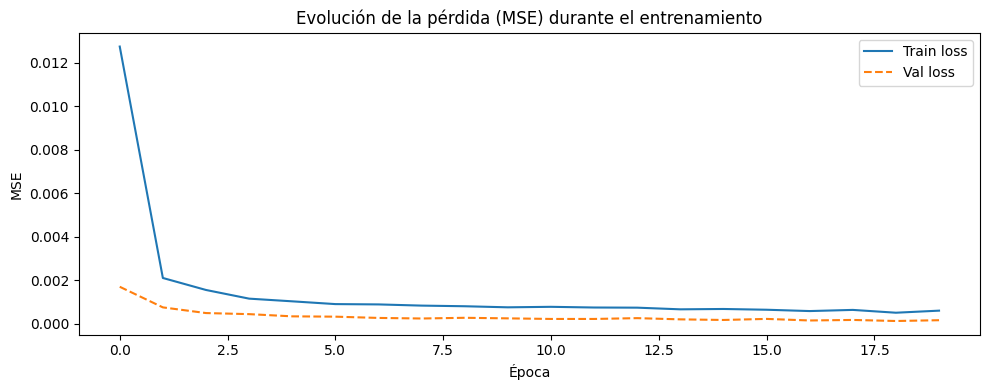


[Evaluación MSE] Calibrando semáforo para IBEX 35...
Umbrales calibrados — Verde<0.000385  Ámbar<0.000587


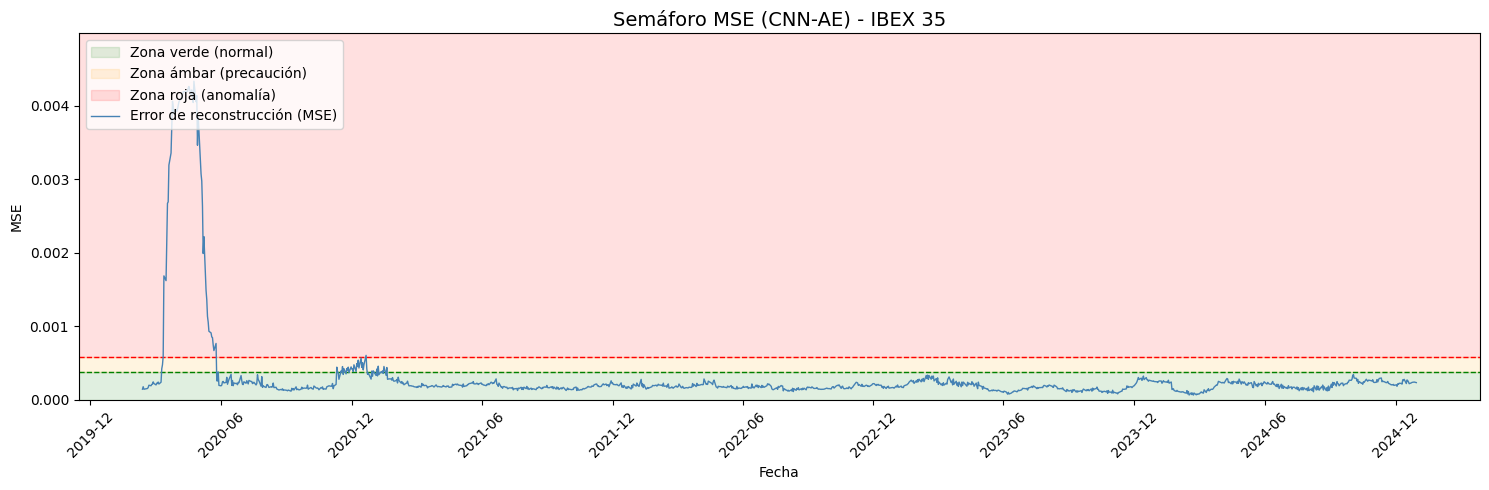

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Descargando datos para ^GSPC...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']

Entrenando Autoencoder para S&P 500...
Entrenando en: cuda


  Epoch  10/20  |  train=0.000656  val=0.003169
  Epoch  20/20  |  train=0.000529  val=0.002959


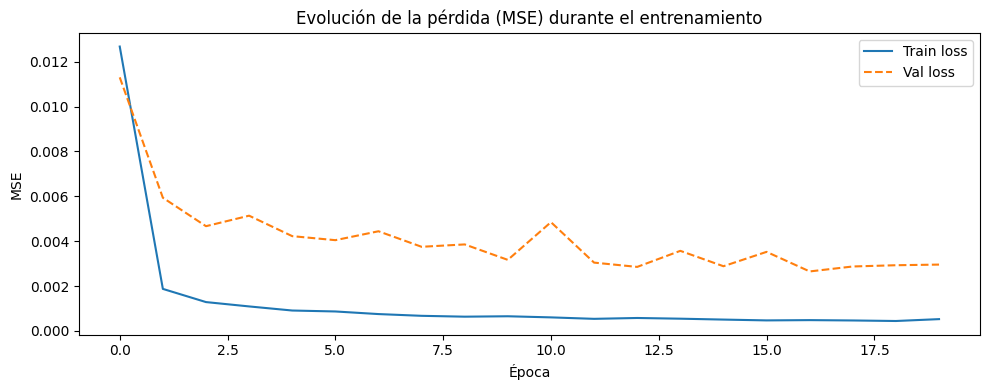


[Evaluación MSE] Calibrando semáforo para S&P 500...
Umbrales calibrados — Verde<0.001307  Ámbar<0.003581


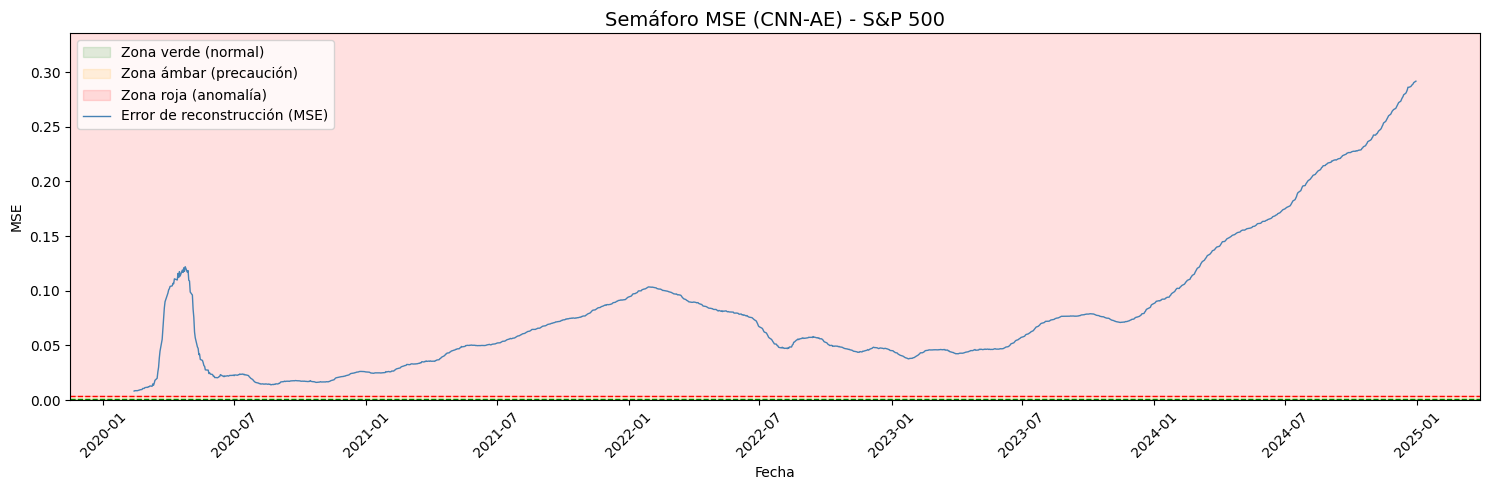

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Descargando datos para GC=F...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']

Entrenando Autoencoder para Oro...
Entrenando en: cuda


  Epoch  10/20  |  train=0.000893  val=0.000368
  Epoch  20/20  |  train=0.000675  val=0.000267


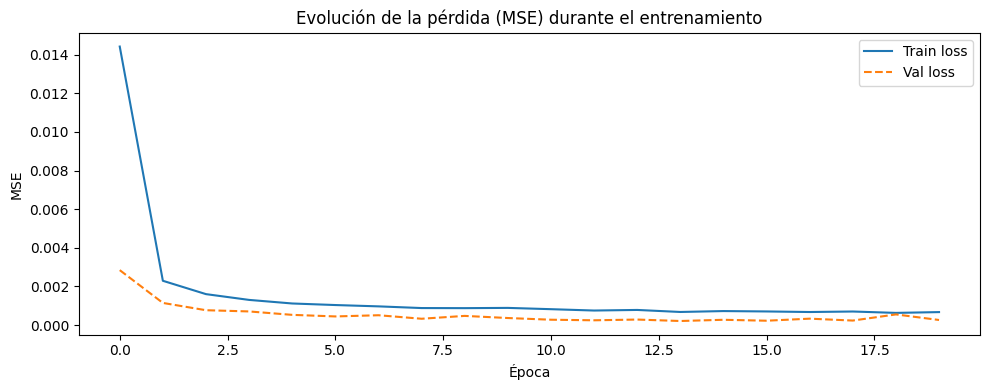


[Evaluación MSE] Calibrando semáforo para Oro...
Umbrales calibrados — Verde<0.000548  Ámbar<0.000781


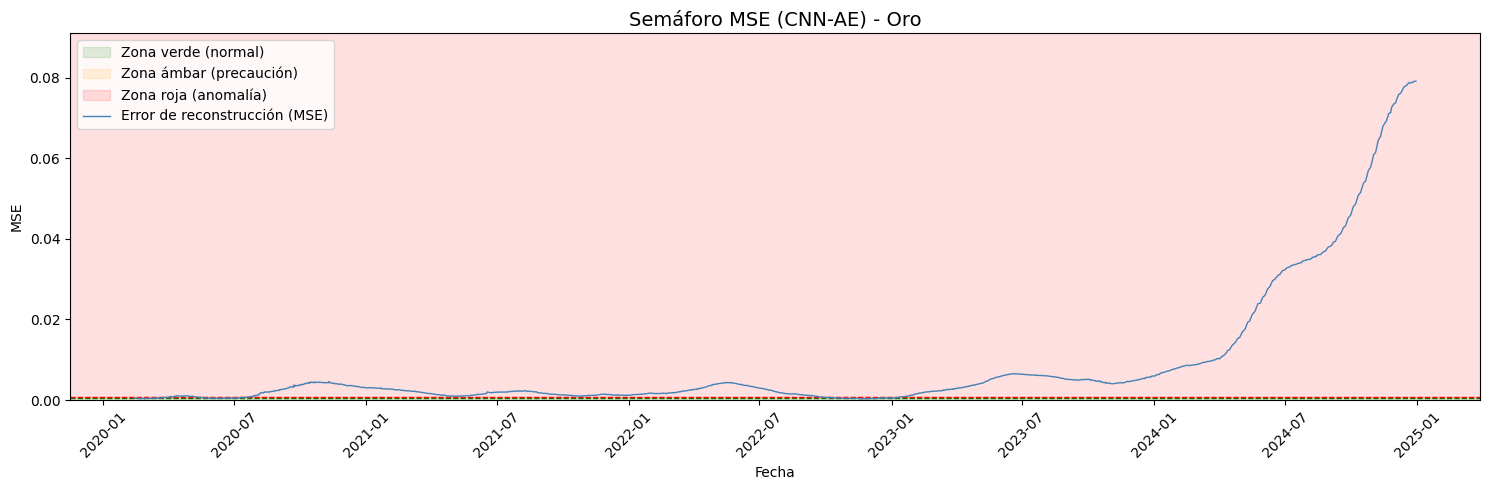

In [41]:
# Parámetros
TICKER = ['^IBEX', '^GSPC', 'GC=F']
START_DATE = '2000-01-01'
END_DATE = '2024-12-31'
STABILITY_END = '2019-12-31'
WINDOW_SIZE = 30
FEATURE_COLS = ['Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'SMA_50']

# 1. Carga y Procesado
for ticker_symbol in TICKER:
    name = assets.get(ticker_symbol, ticker_symbol)
    proc = DataProcessor(ticker=ticker_symbol, start_date=START_DATE, end_date=END_DATE)
    proc.download_data()
    proc.add_features()
    d_df = proc.data

    f_df = d_df[FEATURE_COLS].copy()
    tr_df, ts_df = f_df[:STABILITY_END], f_df[STABILITY_END:]

    scl = MinMaxScaler().fit(tr_df)
    tr_sc = scl.transform(tr_df)
    ts_sc = scl.transform(ts_df)

    # Usamos la función definida localmente
    xtr = make_windows(tr_sc, WINDOW_SIZE)
    xts = make_windows(ts_sc, WINDOW_SIZE)

    # 2. CNN-AE (Entrenamiento y Evaluación de Pérdida)
    ae = ConvAutoencoder(n_features=len(FEATURE_COLS), seq_len=WINDOW_SIZE).to(DEVICE)
    print(f'\nEntrenando Autoencoder para {name}...')
    history = train_autoencoder(ae, xtr, epochs=20, batch_size=64, device=DEVICE)

    # Corrección: plot_training_history no acepta el argumento 'title'
    plot_training_history(history)

    # Visualizar semáforo MSE para este activo específico
    print(f'\n[Evaluación MSE] Calibrando semáforo para {name}...')
    tr_errs = compute_reconstruction_errors(ae, xtr, batch_size=256, device=DEVICE)
    ts_errs = compute_reconstruction_errors(ae, xts, batch_size=256, device=DEVICE)

    # Calibración de umbrales
    thresh = calibrate_thresholds(tr_errs, p_amber=90, p_red=97)

    # Alinear fechas de test para el gráfico de MSE
    t_dates_mse = ts_df.index[WINDOW_SIZE:]
    plot_semaforo(t_dates_mse, ts_errs, thresh, title=f'Semáforo MSE (CNN-AE) - {name}')

## 4) TCN: usar CNN-AE como extractor frozen y entrenar agente multitarea
Explicación: el encoder del `CNN-AE` genera vectores latentes `z` por ventana. Construimos secuencias de `z` (historia temporal) y las pasamos a una `TCN` que alimenta dos cabezas: clasificación (BUY/HOLD/SELL) y regresión (retorno esperado). El diseño sigue el notebook `tcn_agent_semaforoV3Bueno2.ipynb`.

In [42]:
# Esta celda ahora solo contiene la lógica de inicialización específica,
# ya que las clases y funciones están en tcn.py
import torch.nn.functional as F

print("Lógica de TCN cargada desde tcn.py")
# No es necesario definir CausalConv1d, TCN, etc. aquí.

Lógica de TCN cargada desde tcn.py


In [43]:
import torch
import numpy as np
import pandas as pd

# CORRECCIÓN DE DIMENSIONES: El encoder espera [Batch, Channels, Seq_Len]
def get_latent_flat_patched(self, x):
    if x.shape[1] == WINDOW_SIZE:
        x = x.permute(0, 2, 1)
    z = self.encoder(x)
    return torch.flatten(z, start_dim=1)

ConvAutoencoder.get_latent_flat = get_latent_flat_patched
print("Método 'get_latent_flat' (corregido) inyectado en ConvAutoencoder.")

# --- Preparar features adicionales y construir secuencias para la TCN ---
df_full = processor.data.copy()
df_full['SMA_200'] = df_full['Close'].rolling(200).mean()
feat_full = pd.DataFrame(index=df_full.index)
feat_full['ret_5']     = np.log(df_full['Close'] / df_full['Close'].shift(5))
feat_full['ret_20']    = np.log(df_full['Close'] / df_full['Close'].shift(20))
feat_full['px_sma50']  = df_full['Close'] / df_full['SMA_50']  - 1.0
feat_full['px_sma200'] = df_full['Close'] / df_full['SMA_200'] - 1.0
feat_full['rsi']       = df_full['RSI_14'] / 100.0
feat_full['vol']       = df_full['Volatilidad']
feat_full = feat_full.fillna(0.0)

feat_train = feat_full.loc[train_df.index]
feat_test  = feat_full.loc[test_df.index]

fmean, fstd = feat_train.mean(), feat_train.std() + 1e-8
feat_train_sc = ((feat_train - fmean) / fstd).values.astype(np.float32)
feat_test_sc  = ((feat_test  - fmean) / fstd).values.astype(np.float32)

fw_train = feat_train_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_train)]
fw_test  = feat_test_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_test)]

cnn_ae = ae
TCN_SEQ_LEN = 10
TCN_CHANNELS = [32, 16]
DEVICE = device

z_train = build_zf_sequences(cnn_ae, X_train, fw_train, TCN_SEQ_LEN, DEVICE)
z_test  = build_zf_sequences(cnn_ae, X_test,  fw_test,  TCN_SEQ_LEN, DEVICE)

DEC_OFFSET = WINDOW_SIZE + TCN_SEQ_LEN - 2
close_train = df_full['Close'].loc[train_df.index]
close_test  = df_full['Close'].loc[test_df.index]

fwd_train = forward_returns(close_train, DEC_OFFSET, len(z_train), horizon=8)
r1_train = forward_returns(close_train, DEC_OFFSET, len(z_train), horizon=1)

minlen = min(len(z_train), len(fwd_train), len(r1_train))
z_train, fwd_train, r1_train = z_train[:minlen], fwd_train[:minlen], r1_train[:minlen]

Z_DIM = z_train.shape[2]
agent = SemaforoAgent(cnn_ae=cnn_ae, z_dim=Z_DIM, tcn_channels=TCN_CHANNELS, tcn_kernel=3, dropout=0.3, context_dim=64).to(DEVICE)
history, best_ep = train_supervised(agent, z_train, fwd_train, r1_train, epochs=100, lr=3e-4, device=DEVICE)

Método 'get_latent_flat' (corregido) inyectado en ConvAutoencoder.
  Ep  20/100 | val_loss=0.8685 | val_acc=0.489
  Ep  40/100 | val_loss=1.0512 | val_acc=0.487
  Early stopping en epoch 42
  Checkpoint: época 2 | val_loss=0.7697 | val_acc=0.497


### Evaluación del Entrenamiento: Pérdida vs Accuracy
Visualizamos la evolución del Accuracy para verificar que el aprendizaje es estable y no hay overfitting excesivo.

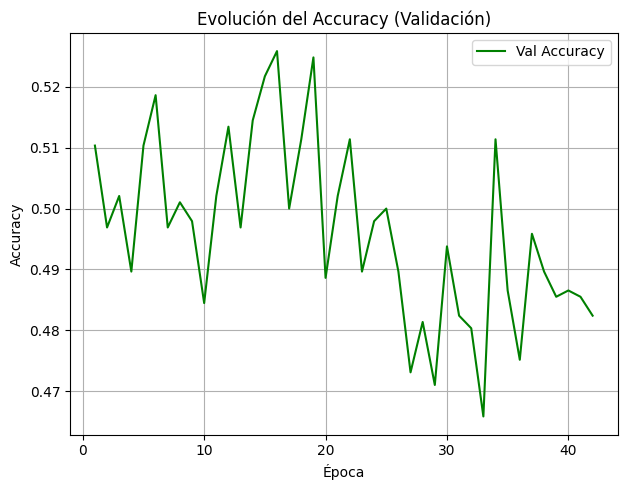


--- REPORTE DE CLASIFICACIÓN (TCN - TEST SET) ---
              precision    recall  f1-score   support

        HOLD       0.00      0.00      0.00       118
         BUY       0.48      0.95      0.64       599
        SELL       0.30      0.03      0.05       524

    accuracy                           0.47      1241
   macro avg       0.26      0.33      0.23      1241
weighted avg       0.36      0.47      0.33      1241



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import torch
import torch.nn.functional as F

def plot_tcn_training(history):
    epochs = range(1, len(history) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, [h for h in history], label='Val Accuracy', color='green')
    plt.title('Evolución del Accuracy (Validación)')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_tcn_training(history)

# Reporte de clasificación detallado para el último set de test
with torch.no_grad():
    agent.eval()
    # CORRECCIÓN: Convertir numpy a tensor antes de .to(DEVICE)
    z_test_tensor = torch.from_numpy(z_test).float().to(DEVICE)
    logits, _ = agent(z_test_tensor)
    preds = torch.argmax(F.softmax(logits, dim=1), dim=1).cpu().numpy()

    # Calculamos targets reales de clasificación
    r1_test = forward_returns(close_test, DEC_OFFSET, len(z_test), horizon=1)
    y_true = np.zeros_like(r1_test, dtype=int)
    y_true[r1_test > 0.001] = 1 # BUY
    y_true[r1_test < -0.001] = 2 # SELL

    print("\n--- REPORTE DE CLASIFICACIÓN (TCN - TEST SET) ---")
    print(classification_report(y_true, preds, target_names=['HOLD', 'BUY', 'SELL'], labels=[0, 1, 2]))

### Comparativa Multiactivo: IBEX 35 vs Oro vs S&P 500
En esta sección automatizamos el pipeline para procesar diferentes activos y comparar cómo se comportan las anomalías (MSE) y las señales del agente en distintos mercados.

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Preparando datos de inferencia específicos por activo...
Descargando datos para ^IBEX...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Descargando datos para ^GSPC...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Descargando datos para GC=F...



/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']

Generando semáforos finales independientes...

>>> Procesando: IBEX 35 (^IBEX) <<<


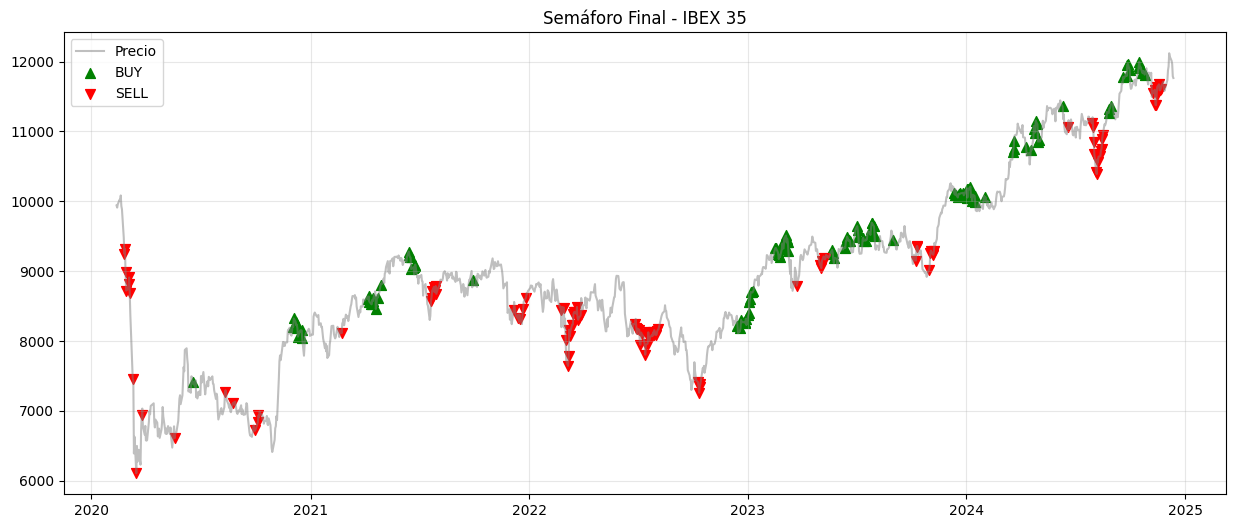

Señales IBEX 35: {'HOLD': 993, 'BUY': 137, 'SELL': 111}

>>> Procesando: S&P 500 (^GSPC) <<<


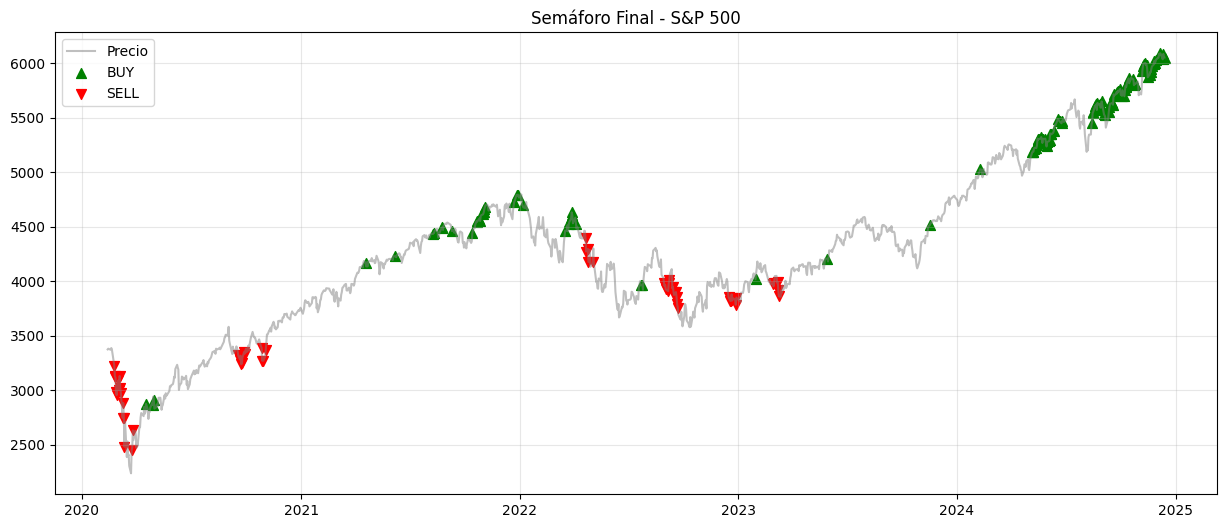

Señales S&P 500: {'HOLD': 1020, 'BUY': 136, 'SELL': 62}

>>> Procesando: Oro (GC=F) <<<


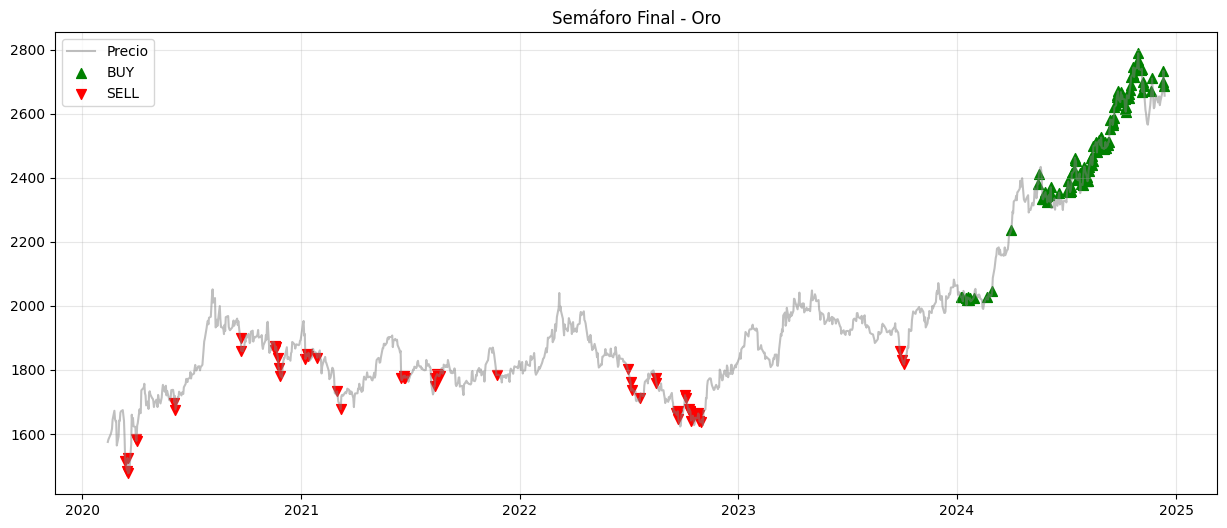

Señales Oro: {'HOLD': 1041, 'BUY': 118, 'SELL': 59}


In [45]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- 1. Almacén de datos y preprocesado específico ---
asset_test_data = {}
print("Preparando datos de inferencia específicos por activo...")

for ticker_symbol in TICKER:
    name = assets.get(ticker_symbol, ticker_symbol)
    proc = DataProcessor(ticker=ticker_symbol, start_date=START_DATE, end_date=END_DATE)
    proc.download_data()
    proc.add_features()

    # Features para el AE
    f_df = proc.data[FEATURE_COLS].copy()
    tr_df, ts_df = f_df[:STABILITY_END], f_df[STABILITY_END:]
    scl = MinMaxScaler().fit(tr_df)
    ts_sc = scl.transform(ts_df)
    xts_ae = make_windows(ts_sc, WINDOW_SIZE)

    # Features extra para la TCN (alineadas con el entrenamiento)
    df_feat = proc.data.copy()
    df_feat['SMA_200'] = df_feat['Close'].rolling(200).mean()
    feat_ext = pd.DataFrame(index=df_feat.index)
    feat_ext['ret_5']     = np.log(df_feat['Close'] / df_feat['Close'].shift(5))
    feat_ext['ret_20']    = np.log(df_feat['Close'] / df_feat['Close'].shift(20))
    feat_ext['px_sma50']  = df_feat['Close'] / df_feat['SMA_50']  - 1.0
    feat_ext['px_sma200'] = df_feat['Close'] / df_feat['SMA_200'] - 1.0
    feat_ext['rsi']       = df_feat['RSI_14'] / 100.0
    feat_ext['vol']       = df_feat['Volatilidad']
    feat_ext = feat_ext.fillna(0.0)

    # Escalado de features TCN (usando fmean/fstd del entrenamiento global)
    feat_test_sc = ((feat_ext.loc[ts_df.index] - fmean) / fstd).values.astype(np.float32)
    fw_ts = feat_test_sc[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(xts_ae)]

    asset_test_data[ticker_symbol] = {
        'xts': xts_ae,
        'fw_test': fw_ts,
        'dates': ts_df.index[WINDOW_SIZE:],
        'close': proc.data['Close']
    }

# --- 2. Inferencia y Generación de Resultados ---
results = {}
print("\nGenerando semáforos finales independientes...")

for ticker, name in assets.items():
    print(f"\n>>> Procesando: {name} ({ticker}) <<<")
    try:
        d = asset_test_data[ticker]

        # Construir secuencias z específicas para este activo
        z_ts_asset = build_zf_sequences(ae, d['xts'], d['fw_test'], TCN_SEQ_LEN, DEVICE)

        # Inferencia con el agente TCN
        signals_raw = run_inference_df(agent, z_ts_asset, d['dates'], DEVICE, coverage=0.30)

        # Filtro de tendencia y guardado
        signals_f = apply_trend_gate_simple(signals_raw, d['close'])
        results[ticker] = (signals_f, d['close'])

        # Visualización
        plot_trading_signals(signals_f, d['close'], title=f'Semáforo Final - {name}')
        print(f"Señales {name}: {signals_f['label'].value_counts().to_dict()}")

    except Exception as e:
        print(f"Error en {name}: {e}")

In [46]:
import numpy as np
import pandas as pd
from metrics import compute_sharpe_ratio, compute_maximum_drawdown, compute_cumulative_return, evaluate_tfm_criteria

def run_comprehensive_backtest(ticker, sig_df, price_series):
    # Precios y retornos para B&H
    rets = price_series.pct_change().reindex(sig_df.index).fillna(0)
    bh_prices = price_series.reindex(sig_df.index)

    # Estrategia SMA
    sma_fast = price_series.rolling(50).mean().reindex(sig_df.index)
    sma_slow = price_series.rolling(200).mean().reindex(sig_df.index)
    sma_signal = (sma_fast > sma_slow).astype(int).shift(1).fillna(0)
    sma_rets = sma_signal * rets
    # Reconstruimos curva de equidad para MDD y Sharpe de SMA
    sma_equity = (1 + sma_rets).cumprod() * bh_prices.iloc[0]

    # Estrategia TCN
    tcn_signal = (sig_df['action'] == 1).astype(int).shift(1).fillna(0)
    tcn_rets = tcn_signal * rets
    tcn_equity = (1 + tcn_rets).cumprod() * bh_prices.iloc[0]

    return {
        'Asset': ticker,
        'B&H Ret': compute_cumulative_return(bh_prices),
        'B&H Sharpe': compute_sharpe_ratio(rets.values),
        'B&H MaxDD': compute_maximum_drawdown(bh_prices)[0],
        'SMA Ret': compute_cumulative_return(sma_equity),
        'SMA Sharpe': compute_sharpe_ratio(sma_rets.values),
        'SMA MaxDD': compute_maximum_drawdown(sma_equity)[0],
        'TCN Ret': compute_cumulative_return(tcn_equity),
        'TCN Sharpe': compute_sharpe_ratio(tcn_rets.values),
        'TCN MaxDD': compute_maximum_drawdown(tcn_equity)[0]
    }

final_comparison = []
if not results:
    print("ADVERTENCIA: El diccionario 'results' está vacío.")
else:
    for tck, (sig, prc) in results.items():
        final_comparison.append(run_comprehensive_backtest(tck, sig, prc))

if final_comparison:
    summary_df = pd.DataFrame(final_comparison).set_index('Asset')
    print("\n--- TABLA DE MÉTRICAS FINALES (MÉTRICAS TFM) ---")
    display(summary_df.style.format({
        'B&H Ret': '{:.2%}', 'B&H MaxDD': '{:.2%}', 'B&H Sharpe': '{:.2f}',
        'SMA Ret': '{:.2%}', 'SMA MaxDD': '{:.2%}', 'SMA Sharpe': '{:.2f}',
        'TCN Ret': '{:.2%}', 'TCN MaxDD': '{:.2%}', 'TCN Sharpe': '{:.2f}'
    }))

    # Evaluación de criterios de éxito para el activo principal (ej: IBEX o S&P)
    # Usamos S&P 500 (^GSPC) como benchmark de Sharpe según tu metrics.py
    if '^IBEX' in summary_df.index and '^GSPC' in summary_df.index:
        print("\n--- EVALUACIÓN DE CRITERIOS DE ÉXITO (IBEX vs Benchmarks) ---")
        evaluate_tfm_criteria(
            sharpe_semaforo=summary_df.loc['^IBEX', 'TCN Sharpe'],
            sharpe_sp500=summary_df.loc['^GSPC', 'B&H Sharpe'],
            mdd_semaforo=summary_df.loc['^IBEX', 'TCN MaxDD'],
            mdd_buy_hold=summary_df.loc['^IBEX', 'B&H MaxDD'],
            retorno_semaforo=summary_df.loc['^IBEX', 'TCN Ret'],
            retorno_ma_referencia=summary_df.loc['^IBEX', 'SMA Ret']
        )
else:
    print("No hay datos para mostrar.")


--- TABLA DE MÉTRICAS FINALES (MÉTRICAS TFM) ---


,B&H Ret,B&H Sharpe,B&H MaxDD,SMA Ret,SMA Sharpe,SMA MaxDD,TCN Ret,TCN Sharpe,TCN MaxDD
Asset,,,,,,,,,
^IBEX,18.35%,0.18,-39.43%,-11.22%,-0.22,-39.43%,-20.14%,-1.30,-21.19%
^GSPC,79.35%,0.58,-33.92%,49.22%,0.45,-33.92%,17.48%,0.37,-3.47%
GC=F,68.62%,0.63,-20.87%,28.96%,0.30,-26.27%,5.04%,-0.17,-9.71%



--- EVALUACIÓN DE CRITERIOS DE ÉXITO (IBEX vs Benchmarks) ---

EVALUACIÓN DE CRITERIOS DE ÉXITO DEL TFM

✓ Criterio 1: Rendimiento Financiero Relativo
  Semáforo retorno: -20.14%
  MA referencia: -11.22%
  Relativo: 179.47% (requerido ≥ 110%)
  Exceso: 79.5% ✓ CUMPLE

✓ Criterio 2: Preservación de Capital
  Semáforo MDD: -21.19%
  Buy & Hold MDD: -39.43%
  Mejora: -18.25% (requerido ≥ 15%)
  Estado: ✗ NO CUMPLE

✓ Criterio 3: Calidad de Inversión (Eficiencia)
  Sharpe Semáforo: -1.3018
  Sharpe S&P 500: 0.5751
  Exceso: -1.8769 (requerido ≥ 0.25)
  Estado: ✗ NO CUMPLE

✗✗✗ ALGUNOS CRITERIOS NO SE CUMPLEN ✗✗✗




### Interpretación de resultados

- **Sharpe Ratio > 1**: Se considera una gestión de riesgo excelente.
- **Max Drawdown**: Queremos que sea lo más pequeño posible (menos negativo). Si el modelo TCN tiene un MaxDD significativamente menor que B&H, está cumpliendo su función de 'semáforo' protegiendo el capital en caídas.
- **Comparación con SMA**: Las medias móviles son el 'benchmark' a batir para cualquier modelo de tendencia. Si el TCN no supera a las SMA, puede que necesitemos ajustar el umbral de confianza (`coverage`) o las features de entrada.

## Conclusiones y siguientes pasos
- Este notebook reproduce el flujo del repositorio: preprocesado → CNN-AE → MSE-semaforo → TCN-agent → semáforo final.
- Recomendaciones: probar varios `FEATURE_COLS`, ajustar `WINDOW_SIZE`, experimentar con la dimensión latente y `TCN` depth/width, y realizar backtests económicos reales (incluyendo costes de transacción).